In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
test = pd.read_csv('/kaggle/input/ariel-data-challenge-2024/test_adc_info.csv')
test.head()

,planet_id,FGS1_adc_offset,FGS1_adc_gain,AIRS-CH0_adc_offset,AIRS-CH0_adc_gain,star
0,499191466,-331.033009,0.823442,-537.6921,0.937944,1


In [4]:
train = pd.read_csv('/kaggle/input/ariel-data-challenge-2024/train_labels.csv')
train.head()

,planet_id,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,wl_9,wl_10,wl_11,wl_12,wl_13,wl_14,wl_15,wl_16,wl_17,wl_18,wl_19,wl_20,wl_21,wl_22,wl_23,wl_24,wl_25,wl_26,wl_27,wl_28,wl_29,wl_30,wl_31,wl_32,wl_33,wl_34,wl_35,wl_36,wl_37,wl_38,wl_39,wl_40,wl_41,wl_42,wl_43,wl_44,wl_45,wl_46,wl_47,wl_48,wl_49,wl_50,wl_51,wl_52,wl_53,wl_54,wl_55,wl_56,wl_57,wl_58,wl_59,wl_60,wl_61,wl_62,wl_63,wl_64,wl_65,wl_66,wl_67,wl_68,wl_69,wl_70,wl_71,wl_72,wl_73,wl_74,wl_75,wl_76,wl_77,wl_78,wl_79,wl_80,wl_81,wl_82,wl_83,wl_84,wl_85,wl_86,wl_87,wl_88,wl_89,wl_90,wl_91,wl_92,wl_93,wl_94,wl_95,wl_96,wl_97,wl_98,wl_99,wl_100,wl_101,wl_102,wl_103,wl_104,wl_105,wl_106,wl_107,wl_108,wl_109,wl_110,wl_111,wl_112,wl_113,wl_114,wl_115,wl_116,wl_117,wl_118,wl_119,wl_120,wl_121,wl_122,wl_123,wl_124,wl_125,wl_126,wl_127,wl_128,wl_129,wl_130,wl_131,wl_132,wl_133,wl_134,wl_135,wl_136,wl_137,wl_138,wl_139,wl_140,wl_141,wl_142,wl_143,wl_144,wl_145,wl_146,wl_147,wl_148,wl_149,wl_150,wl_151,wl_152,wl_153,wl_154,wl_155,wl_156,wl_157,wl_158,wl_159,wl_160,wl_161,wl_162,wl_163,wl_164,wl_165,wl_166,wl_167,wl_168,wl_169,wl_170,wl_171,wl_172,wl_173,wl_174,wl_175,wl_176,wl_177,wl_178,wl_179,wl_180,wl_181,wl_182,wl_183,wl_184,wl_185,wl_186,wl_187,wl_188,wl_189,wl_190,wl_191,wl_192,wl_193,wl_194,wl_195,wl_196,wl_197,wl_198,wl_199,wl_200,wl_201,wl_202,wl_203,wl_204,wl_205,wl_206,wl_207,wl_208,wl_209,wl_210,wl_211,wl_212,wl_213,wl_214,wl_215,wl_216,wl_217,wl_218,wl_219,wl_220,wl_221,wl_222,wl_223,wl_224,wl_225,wl_226,wl_227,wl_228,wl_229,wl_230,wl_231,wl_232,wl_233,wl_234,wl_235,wl_236,wl_237,wl_238,wl_239,wl_240,wl_241,wl_242,wl_243,wl_244,wl_245,wl_246,wl_247,wl_248,wl_249,wl_250,wl_251,wl_252,wl_253,wl_254,wl_255,wl_256,wl_257,wl_258,wl_259,wl_260,wl_261,wl_262,wl_263,wl_264,wl_265,wl_266,wl_267,wl_268,wl_269,wl_270,wl_271,wl_272,wl_273,wl_274,wl_275,wl_276,wl_277,wl_278,wl_279,wl_280,wl_281,wl_282,wl_283
0,785834,0.001086,0.001137,0.001131,0.001124,0.001138,0.001131,0.001123,0.001127,0.001120,0.001116,0.001115,0.001117,0.001121,0.001121,0.001114,0.001104,0.001104,0.001102,0.001093,0.001089,0.001085,0.001088,0.001087,0.001081,0.001079,0.001076,0.001070,0.001067,0.001066,0.001069,0.001073,0.001072,0.001071,0.001074,0.001077,0.001077,0.001076,0.001071,0.001071,0.001075,0.001076,0.001079,0.001085,0.001087,0.001086,0.001088,0.001092,0.001091,0.001089,0.001088,0.001091,0.001098,0.001102,0.001103,0.001105,0.001105,0.001105,0.001112,0.001120,0.001119,0.001117,0.001123,0.001129,0.001129,0.001130,0.001139,0.001155,0.001170,0.001176,0.001170,0.001158,0.001150,0.001149,0.001156,0.001161,0.001166,0.001172,0.001169,0.001159,0.001154,0.001155,0.001156,0.001154,0.001149,0.001148,0.001153,0.001156,0.001155,0.001156,0.001157,0.001155,0.001153,0.001155,0.001156,0.001154,0.001155,0.001164,0.001170,0.001168,0.001167,0.001176,0.001187,0.001189,0.001179,0.001165,0.001162,0.001172,0.001187,0.001188,0.001174,0.001164,0.001166,0.001168,0.001163,0.001160,0.001162,0.001165,0.001168,0.001172,0.001177,0.001183,0.001186,0.001181,0.001176,0.001181,0.001187,0.001184,0.001178,0.001175,0.001175,0.001180,0.001182,0.001175,0.001168,0.001174,0.001188,0.001195,0.001188,0.001180,0.001178,0.001175,0.001173,0.001178,0.001182,0.001176,0.001169,0.001169,0.001169,0.001163,0.001158,0.001157,0.001158,0.001159,0.001162,0.001164,0.001166,0.001168,0.001168,0.001166,0.001163,0.001160,0.001160,0.001162,0.001161,0.001156,0.001152,0.001151,0.001152,0.001152,0.001150,0.001146,0.001143,0.001142,0.001144,0.001145,0.001143,0.001139,0.001139,0.001144,0.001150,0.001154,0.001156,0.001158,0.001160,0.001161,0.001160,0.001154,0.001147,0.001139,0.001136,0.001135,0.001134,0.001133,0.001133,0.001136,0.001138,0.001138,0.001134,0.001131,0.001129,0.001129,0.001131,0.001134,0.001135,0.001133,0.001129,0.001128,0.001129,0.001130,0.001129,0.001127,0.001126,0.001127,0.001128,0.001127,0.001126,0.001125,0.001124,0.001123,0.001121,0.001121,0.001120,0.001119,0.001117,0.001116,0.001116,0.001117,0.001116,0.001115,0.001114,0.001113,0.001113,0.001114,0.001114,0

In [5]:
combined = pd.concat([train,test])
combined.head()

,planet_id,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,wl_9,wl_10,wl_11,wl_12,wl_13,wl_14,wl_15,wl_16,wl_17,wl_18,wl_19,wl_20,wl_21,wl_22,wl_23,wl_24,wl_25,wl_26,wl_27,wl_28,wl_29,wl_30,wl_31,wl_32,wl_33,wl_34,wl_35,wl_36,wl_37,wl_38,wl_39,wl_40,wl_41,wl_42,wl_43,wl_44,wl_45,wl_46,wl_47,wl_48,wl_49,wl_50,wl_51,wl_52,wl_53,wl_54,wl_55,wl_56,wl_57,wl_58,wl_59,wl_60,wl_61,wl_62,wl_63,wl_64,wl_65,wl_66,wl_67,wl_68,wl_69,wl_70,wl_71,wl_72,wl_73,wl_74,wl_75,wl_76,wl_77,wl_78,wl_79,wl_80,wl_81,wl_82,wl_83,wl_84,wl_85,wl_86,wl_87,wl_88,wl_89,wl_90,wl_91,wl_92,wl_93,wl_94,wl_95,wl_96,wl_97,wl_98,wl_99,wl_100,wl_101,wl_102,wl_103,wl_104,wl_105,wl_106,wl_107,wl_108,wl_109,wl_110,wl_111,wl_112,wl_113,wl_114,wl_115,wl_116,wl_117,wl_118,wl_119,wl_120,wl_121,wl_122,wl_123,wl_124,wl_125,wl_126,wl_127,wl_128,wl_129,wl_130,wl_131,wl_132,wl_133,wl_134,wl_135,wl_136,wl_137,wl_138,wl_139,wl_140,wl_141,wl_142,wl_143,wl_144,wl_145,wl_146,wl_147,wl_148,wl_149,wl_150,wl_151,wl_152,wl_153,wl_154,wl_155,wl_156,wl_157,wl_158,wl_159,wl_160,wl_161,wl_162,wl_163,wl_164,wl_165,wl_166,wl_167,wl_168,wl_169,wl_170,wl_171,wl_172,wl_173,wl_174,wl_175,wl_176,wl_177,wl_178,wl_179,wl_180,wl_181,wl_182,wl_183,wl_184,wl_185,wl_186,wl_187,wl_188,wl_189,wl_190,wl_191,wl_192,wl_193,wl_194,wl_195,wl_196,wl_197,wl_198,wl_199,wl_200,wl_201,wl_202,wl_203,wl_204,wl_205,wl_206,wl_207,wl_208,wl_209,wl_210,wl_211,wl_212,wl_213,wl_214,wl_215,wl_216,wl_217,wl_218,wl_219,wl_220,wl_221,wl_222,wl_223,wl_224,wl_225,wl_226,wl_227,wl_228,wl_229,wl_230,wl_231,wl_232,wl_233,wl_234,wl_235,wl_236,wl_237,wl_238,wl_239,wl_240,wl_241,wl_242,wl_243,wl_244,wl_245,wl_246,wl_247,wl_248,wl_249,wl_250,wl_251,wl_252,wl_253,wl_254,wl_255,wl_256,wl_257,wl_258,wl_259,wl_260,wl_261,wl_262,wl_263,wl_264,wl_265,wl_266,wl_267,wl_268,wl_269,wl_270,wl_271,wl_272,wl_273,wl_274,wl_275,wl_276,wl_277,wl_278,wl_279,wl_280,wl_281,wl_282,wl_283,FGS1_adc_offset,FGS1_adc_gain,AIRS-CH0_adc_offset,AIRS-CH0_adc_gain,star
0,785834,0.001086,0.001137,0.001131,0.001124,0.001138,0.001131,0.001123,0.001127,0.001120,0.001116,0.001115,0.001117,0.001121,0.001121,0.001114,0.001104,0.001104,0.001102,0.001093,0.001089,0.001085,0.001088,0.001087,0.001081,0.001079,0.001076,0.001070,0.001067,0.001066,0.001069,0.001073,0.001072,0.001071,0.001074,0.001077,0.001077,0.001076,0.001071,0.001071,0.001075,0.001076,0.001079,0.001085,0.001087,0.001086,0.001088,0.001092,0.001091,0.001089,0.001088,0.001091,0.001098,0.001102,0.001103,0.001105,0.001105,0.001105,0.001112,0.001120,0.001119,0.001117,0.001123,0.001129,0.001129,0.001130,0.001139,0.001155,0.001170,0.001176,0.001170,0.001158,0.001150,0.001149,0.001156,0.001161,0.001166,0.001172,0.001169,0.001159,0.001154,0.001155,0.001156,0.001154,0.001149,0.001148,0.001153,0.001156,0.001155,0.001156,0.001157,0.001155,0.001153,0.001155,0.001156,0.001154,0.001155,0.001164,0.001170,0.001168,0.001167,0.001176,0.001187,0.001189,0.001179,0.001165,0.001162,0.001172,0.001187,0.001188,0.001174,0.001164,0.001166,0.001168,0.001163,0.001160,0.001162,0.001165,0.001168,0.001172,0.001177,0.001183,0.001186,0.001181,0.001176,0.001181,0.001187,0.001184,0.001178,0.001175,0.001175,0.001180,0.001182,0.001175,0.001168,0.001174,0.001188,0.001195,0.001188,0.001180,0.001178,0.001175,0.001173,0.001178,0.001182,0.001176,0.001169,0.001169,0.001169,0.001163,0.001158,0.001157,0.001158,0.001159,0.001162,0.001164,0.001166,0.001168,0.001168,0.001166,0.001163,0.001160,0.001160,0.001162,0.001161,0.001156,0.001152,0.001151,0.001152,0.001152,0.001150,0.001146,0.001143,0.001142,0.001144,0.001145,0.001143,0.001139,0.001139,0.001144,0.001150,0.001154,0.001156,0.001158,0.001160,0.001161,0.001160,0.001154,0.001147,0.001139,0.001136,0.001135,0.001134,0.001133,0.001133,0.001136,0.001138,0.001138,0.001134,0.001131,0.001129,0.001129,0.001131,0.001134,0.001135,0.001133,0.001129,0.001128,0.001129,0.001130,0.001129,0.001127,0.001126,0.001127,0.001128,0.001127,0.001126,0.001125,0.001124,0.001123,0.001121,0.001121,0.001120,0.001119,0.001117,0.001116,0.001116,

In [13]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 674 entries, 0 to 0
Columns: 289 entries, planet_id to star
dtypes: float64(288), int64(1)
memory usage: 1.5 MB


In [14]:
combined.dtypes

planet_id                int64
wl_1                   float64
wl_2                   float64
wl_3                   float64
wl_4                   float64
                        ...   
FGS1_adc_offset        float64
FGS1_adc_gain          float64
AIRS-CH0_adc_offset    float64
AIRS-CH0_adc_gain      float64
star                   float64
Length: 289, dtype: object

In [15]:
combined.columns

Index(['planet_id', 'wl_1', 'wl_2', 'wl_3', 'wl_4', 'wl_5', 'wl_6', 'wl_7',
       'wl_8', 'wl_9',
       ...
       'wl_279', 'wl_280', 'wl_281', 'wl_282', 'wl_283', 'FGS1_adc_offset',
       'FGS1_adc_gain', 'AIRS-CH0_adc_offset', 'AIRS-CH0_adc_gain', 'star'],
      dtype='object', length=289)

In [16]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
planet_id,674.0,2.129344e+09,1.201008e+09,785834.000000,1.116345e+09,2.041834e+09,3.100208e+09,4.286134e+09
wl_1,673.0,2.485777e-03,1.720377e-03,0.000396,1.183097e-03,1.865648e-03,3.527322e-03,7.096563e-03
wl_2,673.0,2.515679e-03,1.719718e-03,0.000396,1.206500e-03,1.904654e-03,3.532582e-03,7.080380e-03
wl_3,673.0,2.509821e-03,1.717223e-03,0.000396,1.206453e-03,1.896304e-03,3.529747e-03,7.077489e-03
wl_4,673.0,2.505278e-03,1.716524e-03,0.000396,1.205906e-03,1.894281e-03,3.529379e-03,7.071717e-03
...,...,...,...,...,...,...,...,...
FGS1_adc_offset,1.0,-3.310330e+02,NaN,-331.033009,-3.310330e+02,-3.310330e+02,-3.310330e+02,-3.310330e+02
FGS1_adc_gain,1.0,8.234420e-01,NaN,0.823442,8.234420e-01,8.234420e-01,8.234420e-01,8.234420e-01
AIRS-CH0_adc_offset,1.0,-5.376921e+02,NaN,-537.692100,-5.376921e+02,-5.376921e+02,-5.376921e+02,-5.376921e+02
AIRS-CH0_adc_gain,1.0,9.379441e-01,NaN,0.937944,9.379441e-01,9.379441e-01,9.379441e-01,9.379441e-01


In [21]:
combined.corr()

,planet_id,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,wl_9,wl_10,wl_11,wl_12,wl_13,wl_14,wl_15,wl_16,wl_17,wl_18,wl_19,wl_20,wl_21,wl_22,wl_23,wl_24,wl_25,wl_26,wl_27,wl_28,wl_29,wl_30,wl_31,wl_32,wl_33,wl_34,wl_35,wl_36,wl_37,wl_38,wl_39,wl_40,wl_41,wl_42,wl_43,wl_44,wl_45,wl_46,wl_47,wl_48,wl_49,wl_50,wl_51,wl_52,wl_53,wl_54,wl_55,wl_56,wl_57,wl_58,wl_59,wl_60,wl_61,wl_62,wl_63,wl_64,wl_65,wl_66,wl_67,wl_68,wl_69,wl_70,wl_71,wl_72,wl_73,wl_74,wl_75,wl_76,wl_77,wl_78,wl_79,wl_80,wl_81,wl_82,wl_83,wl_84,wl_85,wl_86,wl_87,wl_88,wl_89,wl_90,wl_91,wl_92,wl_93,wl_94,wl_95,wl_96,wl_97,wl_98,wl_99,wl_100,wl_101,wl_102,wl_103,wl_104,wl_105,wl_106,wl_107,wl_108,wl_109,wl_110,wl_111,wl_112,wl_113,wl_114,wl_115,wl_116,wl_117,wl_118,wl_119,wl_120,wl_121,wl_122,wl_123,wl_124,wl_125,wl_126,wl_127,wl_128,wl_129,wl_130,wl_131,wl_132,wl_133,wl_134,wl_135,wl_136,wl_137,wl_138,wl_139,wl_140,wl_141,wl_142,wl_143,wl_144,wl_145,wl_146,wl_147,wl_148,wl_149,wl_150,wl_151,wl_152,wl_153,wl_154,wl_155,wl_156,wl_157,wl_158,wl_159,wl_160,wl_161,wl_162,wl_163,wl_164,wl_165,wl_166,wl_167,wl_168,wl_169,wl_170,wl_171,wl_172,wl_173,wl_174,wl_175,wl_176,wl_177,wl_178,wl_179,wl_180,wl_181,wl_182,wl_183,wl_184,wl_185,wl_186,wl_187,wl_188,wl_189,wl_190,wl_191,wl_192,wl_193,wl_194,wl_195,wl_196,wl_197,wl_198,wl_199,wl_200,wl_201,wl_202,wl_203,wl_204,wl_205,wl_206,wl_207,wl_208,wl_209,wl_210,wl_211,wl_212,wl_213,wl_214,wl_215,wl_216,wl_217,wl_218,wl_219,wl_220,wl_221,wl_222,wl_223,wl_224,wl_225,wl_226,wl_227,wl_228,wl_229,wl_230,wl_231,wl_232,wl_233,wl_234,wl_235,wl_236,wl_237,wl_238,wl_239,wl_240,wl_241,wl_242,wl_243,wl_244,wl_245,wl_246,wl_247,wl_248,wl_249,wl_250,wl_251,wl_252,wl_253,wl_254,wl_255,wl_256,wl_257,wl_258,wl_259,wl_260,wl_261,wl_262,wl_263,wl_264,wl_265,wl_266,wl_267,wl_268,wl_269,wl_270,wl_271,wl_272,wl_273,wl_274,wl_275,wl_276,wl_277,wl_278,wl_279,wl_280,wl_281,wl_282,wl_283,FGS1_adc_offset,FGS1_adc_gain,AIRS-CH0_adc_offset,AIRS-CH0_adc_gain,star
planet_id,1.000000,0.095190,0.095111,0.094688,0.094030,0.094733,0.094652,0.094140,0.093904,0.093564,0.093457,0.093338,0.093167,0.093077,0.093203,0.093418,0.093480,0.093640,0.093800,0.093723,0.093602,0.093653,0.093912,0.094142,0.094312,0.094538,0.094719,0.094787,0.094880,0.095060,0.095390,0.095674,0.095689,0.095616,0.095604,0.095653,0.095758,0.095806,0.095756,0.095801,0.095920,0.095976,0.096036,0.096086,0.096054,0.096017,0.096100,0.096271,0.096334,0.096219,0.096147,0.096265,0.096409,0.096374,0.096199,0.096084,0.096037,0.095984,0.096026,0.096140,0.096092,0.095974,0.095967,0.095973,0.095928,0.095941,0.096123,0.096490,0.096930,0.097067,0.096771,0.096352,0.096080,0.096108,0.096316,0.096383,0.096429,0.096631,0.096628,0.096378,0.096238,0.096198,0.096248,0.096261,0.096031,0.095788,0.095749,0.095745,0.095571,0.095326,0.095201,0.095165,0.095320,0.095569,0.095367,0.094841,0.094690,0.094982,0.095169,0.094947,0.094853,0.095423,0.096151,0.096266,0.095673,0.094939,0.094767,0.095419,0.096310,0.096360,0.095508,0.094871,0.094813,0.094779,0.094654,0.094560,0.094506,0.094593,0.094795,0.094994,0.095237,0.095540,0.095665,0.095504,0.095452,0.095781,0.096053,0.095983,0.095924,0.096014,0.096100,0.096225,0.096274,0.096115,0.096090,0.096491,0.097050,0.097339,0.097287,0.097205,0.097265,0.097274,0.097244,0.097409,0.097596,0.097542,0.097458,0.097553,0.097641,0.097600,0.097581,0.097657,0.097782,0.097964,0.098164,0.098287,0.098325,0.098329,0.098332,0.098323,0.098275,0.098199,0.098157,0.098169,0.098156,0.098078,0.098002,0.097975,0.097952,0.097891,0.097814,0.097751,0.097692,0.097634,0.097592,0.097560,0.097501,0.097428,0.097450,0.097661,0.097999,0.098283,0.098448,0.098580,0.098714,0.098782,0.098708,0.098479,0.098162,0.097874,0.097690,0.097596,0.097529,0.097460,0.097445,0.097520,0.097616,0.097632,0.097571,0.097507,0.097484,0.097491,0.097528,0.097575,0.097578,0.097515,0.097444,0.097427,0.097451,0.097457,0.097422,0.097375,0.097358,0.097371,0.097380,0.097367,0.097351,0.097344,0.097325,0.097279,0.097221,0.097168,0.097115,0.097059,0.097003,0.096955

<Axes: >

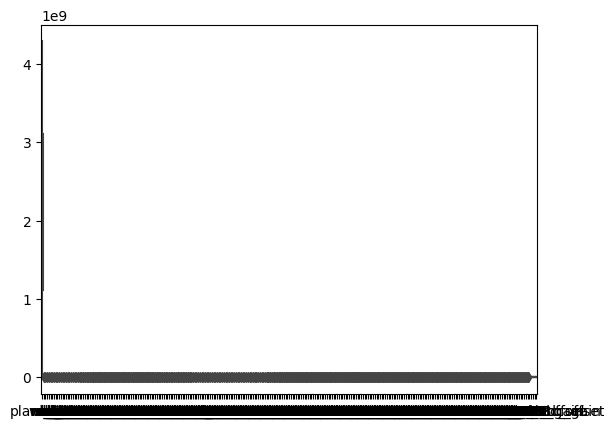

In [22]:
sns.boxplot(combined)

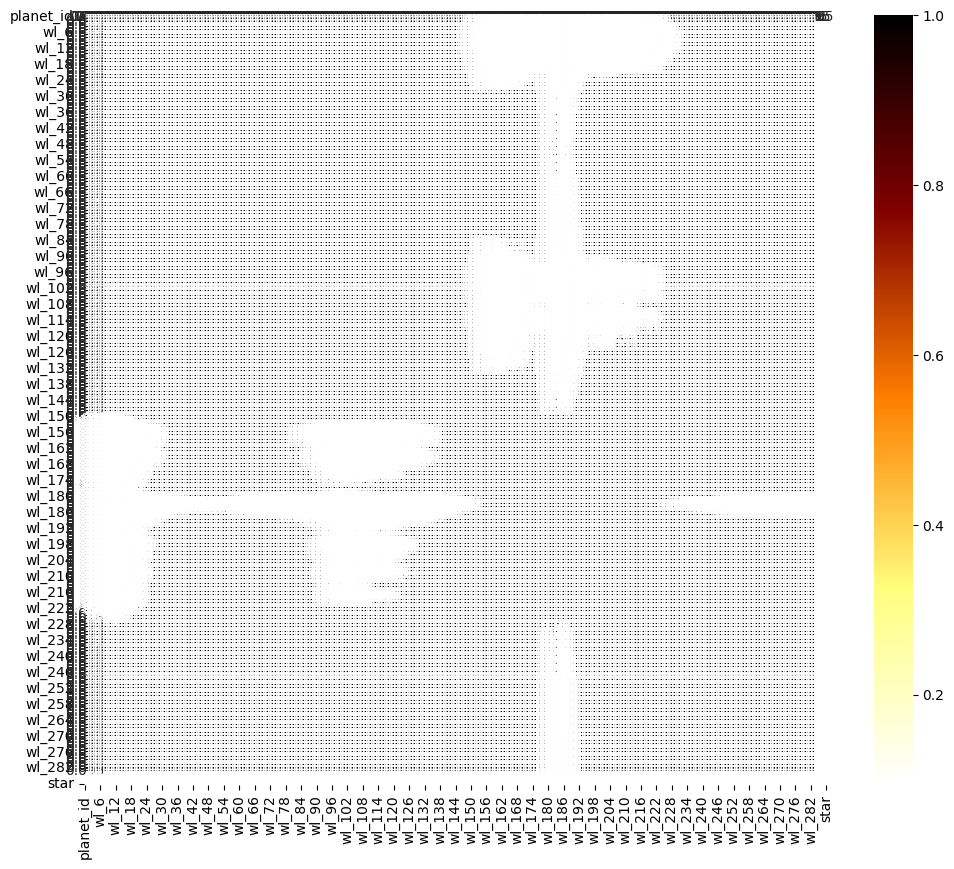

In [24]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

In [26]:
combined.shape


(674, 289)

In [40]:
cat_cols = combined.select_dtypes(include='object')

In [41]:
for i in cat_cols:
    ([combined[i].value_counts()])
    print(i)
    print('_'*50)

In [32]:
combined.head()

,planet_id,wl_1,wl_2,wl_3,wl_4,wl_5,wl_6,wl_7,wl_8,wl_9,wl_10,wl_11,wl_12,wl_13,wl_14,wl_15,wl_16,wl_17,wl_18,wl_19,wl_20,wl_21,wl_22,wl_23,wl_24,wl_25,wl_26,wl_27,wl_28,wl_29,wl_30,wl_31,wl_32,wl_33,wl_34,wl_35,wl_36,wl_37,wl_38,wl_39,wl_40,wl_41,wl_42,wl_43,wl_44,wl_45,wl_46,wl_47,wl_48,wl_49,wl_50,wl_51,wl_52,wl_53,wl_54,wl_55,wl_56,wl_57,wl_58,wl_59,wl_60,wl_61,wl_62,wl_63,wl_64,wl_65,wl_66,wl_67,wl_68,wl_69,wl_70,wl_71,wl_72,wl_73,wl_74,wl_75,wl_76,wl_77,wl_78,wl_79,wl_80,wl_81,wl_82,wl_83,wl_84,wl_85,wl_86,wl_87,wl_88,wl_89,wl_90,wl_91,wl_92,wl_93,wl_94,wl_95,wl_96,wl_97,wl_98,wl_99,wl_100,wl_101,wl_102,wl_103,wl_104,wl_105,wl_106,wl_107,wl_108,wl_109,wl_110,wl_111,wl_112,wl_113,wl_114,wl_115,wl_116,wl_117,wl_118,wl_119,wl_120,wl_121,wl_122,wl_123,wl_124,wl_125,wl_126,wl_127,wl_128,wl_129,wl_130,wl_131,wl_132,wl_133,wl_134,wl_135,wl_136,wl_137,wl_138,wl_139,wl_140,wl_141,wl_142,wl_143,wl_144,wl_145,wl_146,wl_147,wl_148,wl_149,wl_150,wl_151,wl_152,wl_153,wl_154,wl_155,wl_156,wl_157,wl_158,wl_159,wl_160,wl_161,wl_162,wl_163,wl_164,wl_165,wl_166,wl_167,wl_168,wl_169,wl_170,wl_171,wl_172,wl_173,wl_174,wl_175,wl_176,wl_177,wl_178,wl_179,wl_180,wl_181,wl_182,wl_183,wl_184,wl_185,wl_186,wl_187,wl_188,wl_189,wl_190,wl_191,wl_192,wl_193,wl_194,wl_195,wl_196,wl_197,wl_198,wl_199,wl_200,wl_201,wl_202,wl_203,wl_204,wl_205,wl_206,wl_207,wl_208,wl_209,wl_210,wl_211,wl_212,wl_213,wl_214,wl_215,wl_216,wl_217,wl_218,wl_219,wl_220,wl_221,wl_222,wl_223,wl_224,wl_225,wl_226,wl_227,wl_228,wl_229,wl_230,wl_231,wl_232,wl_233,wl_234,wl_235,wl_236,wl_237,wl_238,wl_239,wl_240,wl_241,wl_242,wl_243,wl_244,wl_245,wl_246,wl_247,wl_248,wl_249,wl_250,wl_251,wl_252,wl_253,wl_254,wl_255,wl_256,wl_257,wl_258,wl_259,wl_260,wl_261,wl_262,wl_263,wl_264,wl_265,wl_266,wl_267,wl_268,wl_269,wl_270,wl_271,wl_272,wl_273,wl_274,wl_275,wl_276,wl_277,wl_278,wl_279,wl_280,wl_281,wl_282,wl_283,FGS1_adc_offset,FGS1_adc_gain,AIRS-CH0_adc_offset,AIRS-CH0_adc_gain,star
0,785834,0.001086,0.001137,0.001131,0.001124,0.001138,0.001131,0.001123,0.001127,0.001120,0.001116,0.001115,0.001117,0.001121,0.001121,0.001114,0.001104,0.001104,0.001102,0.001093,0.001089,0.001085,0.001088,0.001087,0.001081,0.001079,0.001076,0.001070,0.001067,0.001066,0.001069,0.001073,0.001072,0.001071,0.001074,0.001077,0.001077,0.001076,0.001071,0.001071,0.001075,0.001076,0.001079,0.001085,0.001087,0.001086,0.001088,0.001092,0.001091,0.001089,0.001088,0.001091,0.001098,0.001102,0.001103,0.001105,0.001105,0.001105,0.001112,0.001120,0.001119,0.001117,0.001123,0.001129,0.001129,0.001130,0.001139,0.001155,0.001170,0.001176,0.001170,0.001158,0.001150,0.001149,0.001156,0.001161,0.001166,0.001172,0.001169,0.001159,0.001154,0.001155,0.001156,0.001154,0.001149,0.001148,0.001153,0.001156,0.001155,0.001156,0.001157,0.001155,0.001153,0.001155,0.001156,0.001154,0.001155,0.001164,0.001170,0.001168,0.001167,0.001176,0.001187,0.001189,0.001179,0.001165,0.001162,0.001172,0.001187,0.001188,0.001174,0.001164,0.001166,0.001168,0.001163,0.001160,0.001162,0.001165,0.001168,0.001172,0.001177,0.001183,0.001186,0.001181,0.001176,0.001181,0.001187,0.001184,0.001178,0.001175,0.001175,0.001180,0.001182,0.001175,0.001168,0.001174,0.001188,0.001195,0.001188,0.001180,0.001178,0.001175,0.001173,0.001178,0.001182,0.001176,0.001169,0.001169,0.001169,0.001163,0.001158,0.001157,0.001158,0.001159,0.001162,0.001164,0.001166,0.001168,0.001168,0.001166,0.001163,0.001160,0.001160,0.001162,0.001161,0.001156,0.001152,0.001151,0.001152,0.001152,0.001150,0.001146,0.001143,0.001142,0.001144,0.001145,0.001143,0.001139,0.001139,0.001144,0.001150,0.001154,0.001156,0.001158,0.001160,0.001161,0.001160,0.001154,0.001147,0.001139,0.001136,0.001135,0.001134,0.001133,0.001133,0.001136,0.001138,0.001138,0.001134,0.001131,0.001129,0.001129,0.001131,0.001134,0.001135,0.001133,0.001129,0.001128,0.001129,0.001130,0.001129,0.001127,0.001126,0.001127,0.001128,0.001127,0.001126,0.001125,0.001124,0.001123,0.001121,0.001121,0.001120,0.001119,0.001117,0.001116,0.001116,

In [34]:
num_cols = combined.select_dtypes(include='number')

In [35]:
for i in num_cols:
    ([combined[i].value_counts()])
    print(i)
    print('_'*50)

planet_id
__________________________________________________
wl_1
__________________________________________________
wl_2
__________________________________________________
wl_3
__________________________________________________
wl_4
__________________________________________________
wl_5
__________________________________________________
wl_6
__________________________________________________
wl_7
__________________________________________________
wl_8
__________________________________________________
wl_9
__________________________________________________
wl_10
__________________________________________________
wl_11
__________________________________________________
wl_12
__________________________________________________
wl_13
__________________________________________________
wl_14
__________________________________________________
wl_15
__________________________________________________
wl_16
__________________________________________________
wl_17
______________________________

<Axes: >

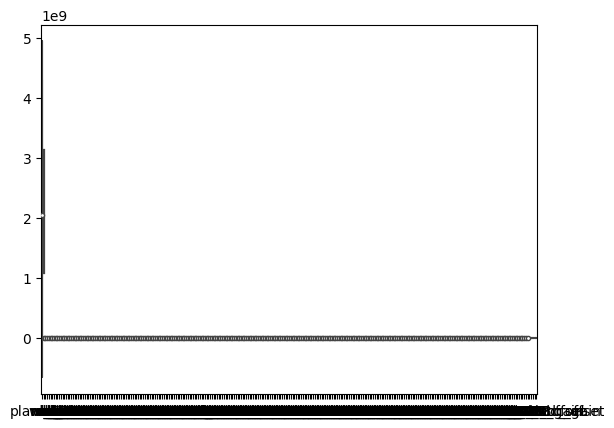

In [42]:
sns.violinplot(combined)

<Axes: >

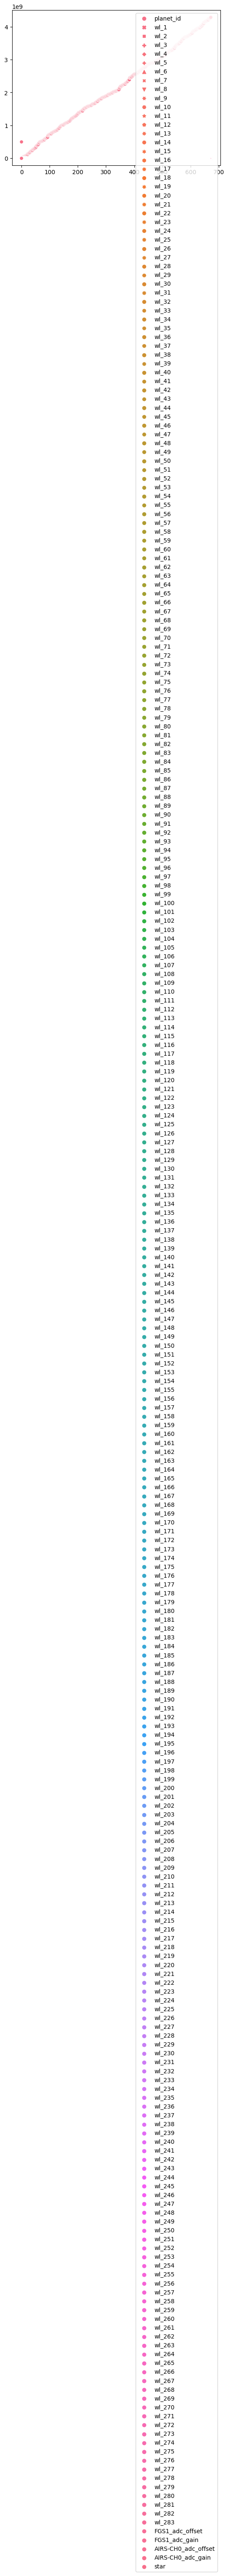

In [43]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


<Axes: >

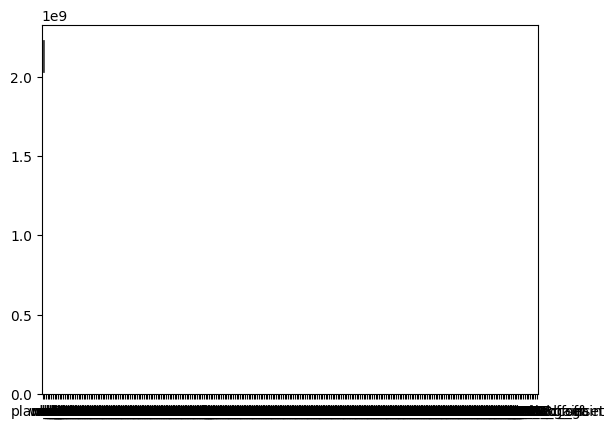

In [6]:
sns.barplot(combined)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/tmp/ipykernel_33/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singula

<Axes: ylabel='Density'>

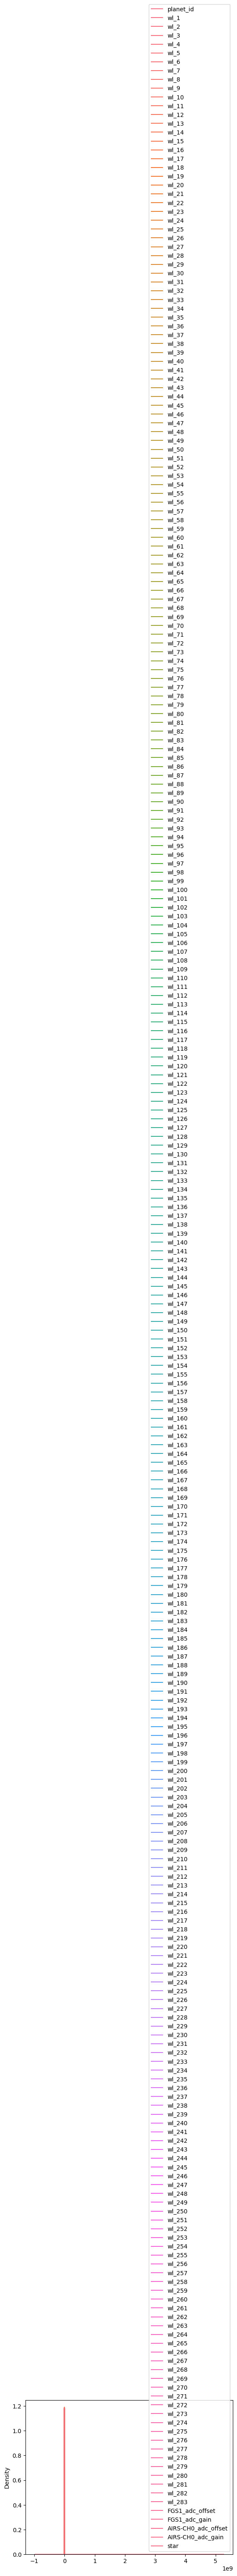

In [7]:
sns.kdeplot(combined)

<Axes: ylabel='count'>

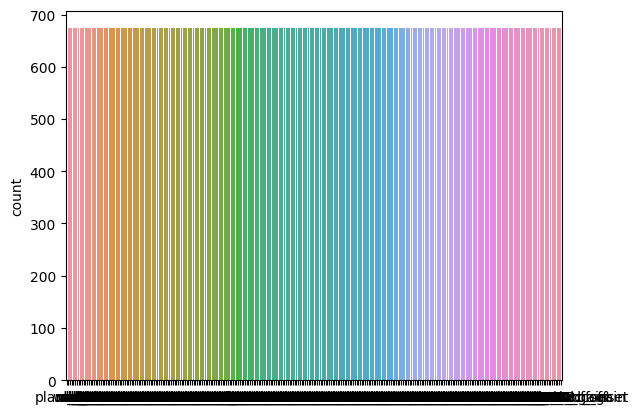

In [13]:
sns.countplot(combined)

In [12]:
combined.skew()

planet_id              0.012838
wl_1                   0.915701
wl_2                   0.908209
wl_3                   0.911610
wl_4                   0.914065
                         ...   
FGS1_adc_offset             NaN
FGS1_adc_gain               NaN
AIRS-CH0_adc_offset         NaN
AIRS-CH0_adc_gain           NaN
star                        NaN
Length: 289, dtype: float64

In [10]:
combined.kurtosis()

planet_id             -1.111641
wl_1                  -0.330056
wl_2                  -0.340307
wl_3                  -0.335011
wl_4                  -0.331308
                         ...   
FGS1_adc_offset             NaN
FGS1_adc_gain               NaN
AIRS-CH0_adc_offset         NaN
AIRS-CH0_adc_gain           NaN
star                        NaN
Length: 289, dtype: float64